In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

In [2]:
def make_reg(add_noize=False):
    xs = np.linspace(0, 10, 100)
    ys = xs + np.random.random(xs.shape)*1.32 - 1

    if add_noize:
        ys[25:45] *= (np.random.random(20)*2)
    
    return xs.reshape(-1, 1), ys

In [3]:
ideal_ds = [
    make_reg(),
    make_reg(),
    make_reg()
]

noize_ds = make_reg(True)

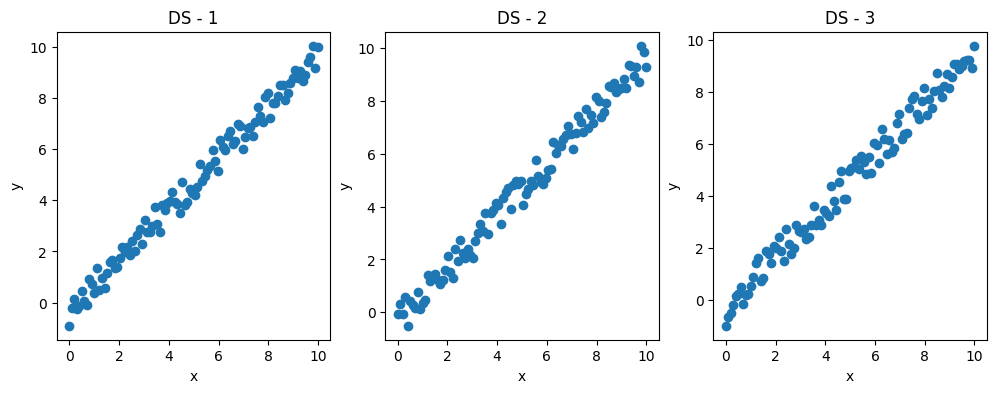

In [4]:
plt.figure(figsize=(12,4))

for i, (xs, ys) in enumerate(ideal_ds, 1):
    plt.subplot(1, 3, i)
    plt.scatter(xs, ys)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'DS - {i}')

Text(0.5, 1.0, 'Noize ds')

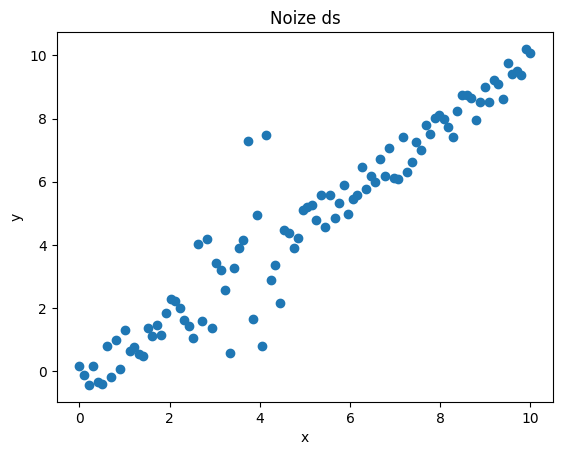

In [5]:
plt.scatter(noize_ds[0], noize_ds[1])
plt.xlabel('x')
plt.ylabel('y')
plt.title('Noize ds')

In [6]:
model = LinearRegression()

model.fit(*ideal_ds[0])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

for i, (xs, ys) in enumerate(ideal_ds):
    np.savetxt(f'ideal_x_{i}.txt', xs)
    np.savetxt(f'ideal_y_{i}.txt', ys)

np.savetxt('noise_x.txt', noize_ds[0])
np.savetxt('noise_y.txt', noize_ds[1])

In [8]:
[
    (
        mean_absolute_percentage_error(ys, model.predict(xs)),
        r2_score(ys, model.predict(xs))
    )
    for xs, ys in ideal_ds
]

[(0.22289417583406604, 0.9863182369159872),
 (0.25522444990806625, 0.9836011187680306),
 (0.20236944576474664, 0.9797101710921327)]

In [9]:
%%writefile test_model.py

import pickle
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

root_p = Path('./')

ideal_ds_paths = []
ideal_xs_path = list(root_p.rglob('ideal_x*.txt'))
ideal_ys_path = list(root_p.rglob('ideal_y*.txt'))

ideal_xs_path.sort()
ideal_ys_path.sort()

print(ideal_xs_path, ideal_ys_path)

ideal_ds = [
    (np.loadtxt(str(x)).reshape(-1, 1), np.loadtxt(str(y)))
    for x, y in zip(ideal_xs_path, ideal_ys_path)
]
noise_ds = (
    np.loadtxt('noise_x.txt').reshape(-1, 1),
    np.loadtxt('noise_y.txt')
)

with open('model.pkl', 'rb') as f:
    model: LinearRegression = pickle.load(f)


MAPE_THRESHOLD = 0.4
R2_THRESHOLD = 0.9


def evaluate(model: LinearRegression, xs: np.ndarray, ys: np.ndarray):
    preds = model.predict(xs)

    return (
        mean_absolute_percentage_error(ys, preds),
        r2_score(ys, preds)
    )


def test_ds_1():
    mape, r2 = evaluate(model, *ideal_ds[0])

    assert mape < MAPE_THRESHOLD
    assert r2 > R2_THRESHOLD


def test_ds_2():
    mape, r2 = evaluate(model, *ideal_ds[1])

    assert mape < MAPE_THRESHOLD
    assert r2 > R2_THRESHOLD


def test_ds_3():
    mape, r2 = evaluate(model, *ideal_ds[2])

    assert mape < MAPE_THRESHOLD
    assert r2 > R2_THRESHOLD


def test_ds_noise():
    mape, r2 = evaluate(model, *noise_ds)

    assert mape < MAPE_THRESHOLD
    assert r2 > R2_THRESHOLD

Writing test_model.py


In [10]:
!pytest

============================= test session starts =============================
platform win32 -- Python 3.12.8, pytest-9.0.3, pluggy-1.6.0
rootdir: d:\GitProjects\mlops_practice
configfile: pyproject.toml
plugins: anyio-4.13.0, hydra-core-1.3.2
collected 4 items

test_model.py ...F                                                       [100%]

================================== FAILURES ===================================
________________________________ test_ds_noise ________________________________

    def test_ds_noise():
        mape, r2 = evaluate(model, *noise_ds)
    
>       assert mape < MAPE_THRESHOLD
E       assert 0.4530111398041835 < 0.4

test_model.py:71: AssertionError
=========================== short test summary info ===========================
FAILED test_model.py::test_ds_noise - assert 0.4530111398041835 < 0.4
========================= 1 failed, 3 passed in 2.83s =========================
